# Détection de Tweets Suspects - Pipeline ML Complet
**Auteur : Alassane SOMA | Université Virtuelle du Burkina Faso (UV-BF) | 2026**  
**Encadrant : Dr. Abdoul Kader KABORE**

---
### Comment utiliser ce notebook ?
1. **Upload** le fichier `tweets_suspect.csv` (Upload)
2. **Exécute** les cellules dans l'ordre avec `Shift+Enter` ou **Runtime vs Run All**
3. C'est tout ! Chaque section est indépendante et commentée.

---
## CELLULE 0 - Installation des librairies

In [ ]:
# Installation des librairies nécessaires
!pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn -q
print('Librairies installées avec succès')

Librairies installées avec succès


---
## CELLULE 1 - Import des librairies

In [ ]:
import pandas as pd
import numpy as np
import re
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE

np.random.seed(42)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11})

print(' Tous les imports réussis')

 Tous les imports réussis


---
##  CELLULE 2 - Chargement du dataset
>  **Assure-toi d'avoir uploadé `tweets_suspect.csv` avant d'exécuter cette cellule !**

In [ ]:
# Chargement du dataset
df = pd.read_csv('tweets_suspect.csv')

df['label'] = df['label'].map({0: 1, 1: 0})

print(f' Dataset chargé : {df.shape[0]:,} tweets, {df.shape[1]} colonnes')
print(f'\nColonnes : {list(df.columns)}')
print(f'\n--- Distribution des labels ---')
print(df['label'].value_counts())
print(f'\n--- Aperçu des données ---')
df.head()

 Dataset chargé : 60,000 tweets, 2 colonnes

Colonnes : ['message', 'label']

--- Distribution des labels ---
label
0    53855
1     6145
Name: count, dtype: int64

--- Aperçu des données ---


,message,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,1
4,"@nationwideclass no, it's not behaving at all....",0


---
## PARTIE 1 - Exploration des données (EDA)

In [ ]:
# Statistiques descriptives
df['longueur'] = df['message'].str.len()
df['nb_mots']  = df['message'].str.split().str.len()

print('=== Statistiques générales ===')
print(f'Total tweets     : {len(df):,}')
print(f'Suspects (1)     : {(df["label"]==1).sum():,} ({(df["label"]==1).mean()*100:.1f}%)')
print(f'Normaux  (0)     : {(df["label"]==0).sum():,} ({(df["label"]==0).mean()*100:.1f}%)')
print(f'Longueur moyenne : {df["longueur"].mean():.1f} caractères')
print(f'Mots moyens      : {df["nb_mots"].mean():.1f} mots/tweet')
print(f'Valeurs manq.    : {df["message"].isna().sum()}')

print('\n=== Statistiques par classe ===')
df.groupby('label')[['longueur','nb_mots']].describe().round(2)

=== Statistiques générales ===
Total tweets     : 60,000
Suspects (1)     : 6,145 (10.2%)
Normaux  (0)     : 53,855 (89.8%)
Longueur moyenne : 73.7 caractères
Mots moyens      : 13.1 mots/tweet
Valeurs manq.    : 0

=== Statistiques par classe ===


longueur                                               nb_mots         \
         count   mean    std  min   25%   50%    75%    max    count   mean   
label                                                                         
0      53855.0  72.28  35.87  6.0  43.0  67.0  100.0  168.0  53855.0  12.82   
1       6145.0  86.65  35.97  9.0  57.0  87.0  120.0  186.0   6145.0  15.57   

                                          
        std  min   25%   50%   75%   max  
label                                     
0      6.83  1.0   7.0  12.0  18.0  34.0  
1      6.81  1.0  10.0  16.0  21.0  34.0

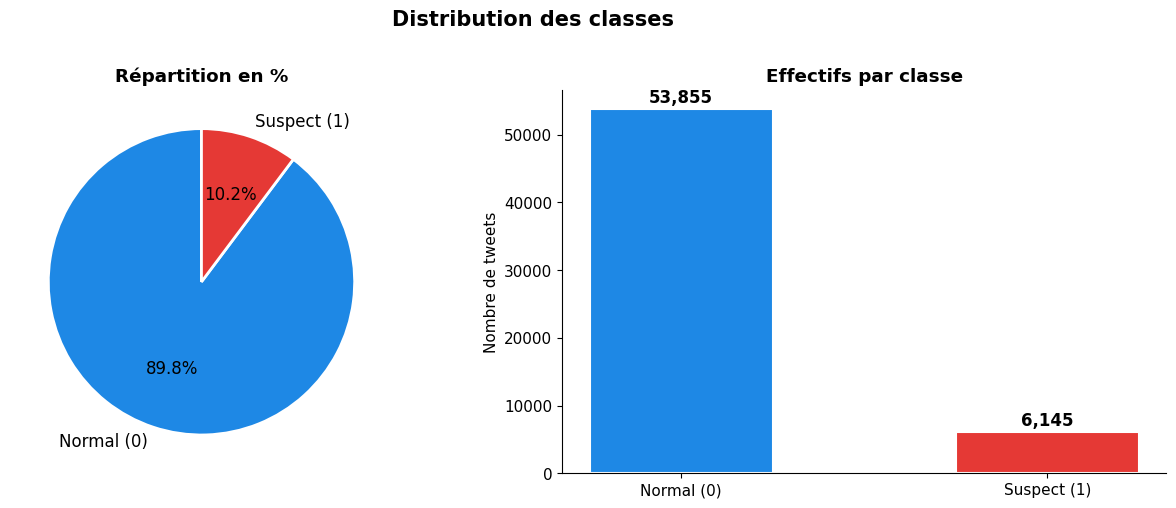

 Figure 1 sauvegardée


In [ ]:
# Figure 1 : Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribution des classes', fontsize=15, fontweight='bold', y=1.01)

counts = df['label'].value_counts().sort_index()
colors = ['#1E88E5', '#E53935']

axes[0].pie(counts.values,
            labels=['Normal (0)', 'Suspect (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Répartition en %', fontweight='bold')

bars = axes[1].bar(['Normal (0)', 'Suspect (1)'], counts.values,
                   color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 300, f'{val:,}',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nombre de tweets')
axes[1].set_title('Effectifs par classe', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 1 sauvegardée')

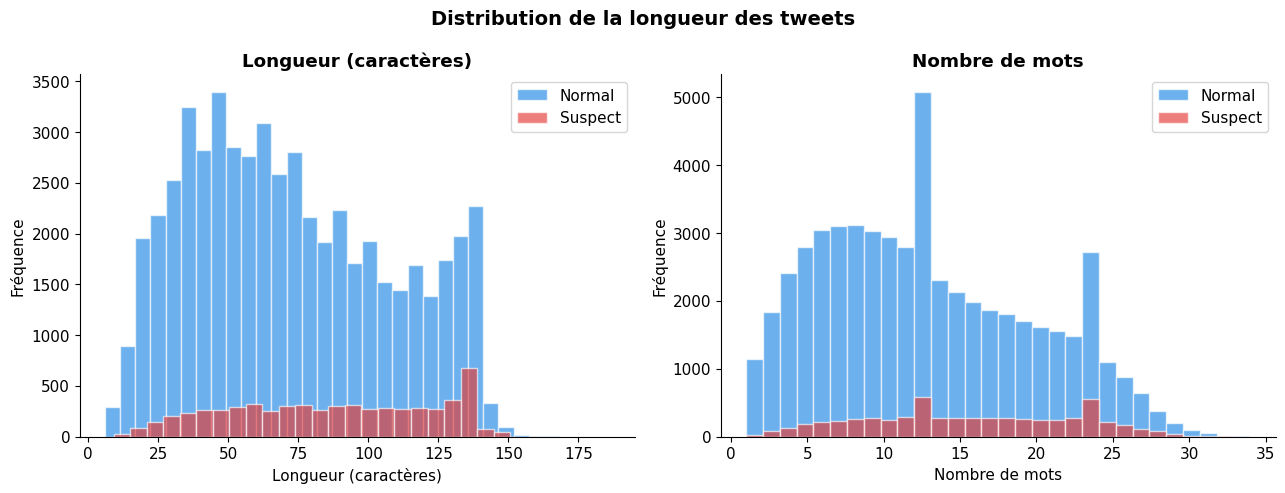

 Figure 2 sauvegardée


In [ ]:
# Figure 2 : Longueur des tweets par classe
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribution de la longueur des tweets', fontsize=14, fontweight='bold')

for col, titre, ax in zip(
        ['longueur', 'nb_mots'],
        ['Longueur (caractères)', 'Nombre de mots'],
        axes):
    for lbl, color, name in [(0,'#1E88E5','Normal'),(1,'#E53935','Suspect')]:
        ax.hist(df[df['label']==lbl][col], bins=30,
                alpha=0.65, color=color, label=name, edgecolor='white')
    ax.set_title(titre, fontweight='bold')
    ax.set_xlabel(titre)
    ax.set_ylabel('Fréquence')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig2_longueur.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 2 sauvegardée')

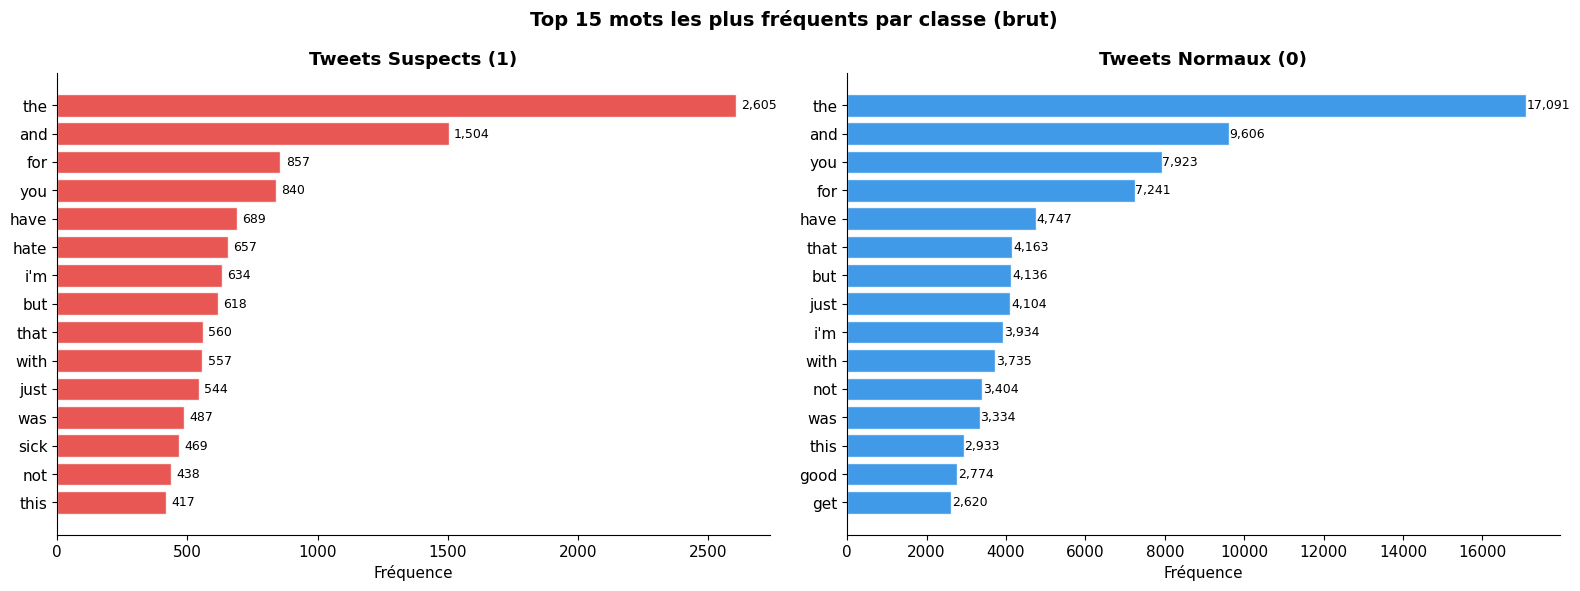

 Figure 3 sauvegardée


In [ ]:
# Figure 3 : Top 15 mots les plus fréquents par classe
def top_mots(textes, n=15):
    c = Counter()
    for t in textes:
        c.update([w for w in str(t).lower().split() if len(w) > 2])
    return c.most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 15 mots les plus fréquents par classe (brut)', fontsize=14, fontweight='bold')

for ax, lbl, color, titre in zip(
        axes, [1, 0],
        ['#E53935', '#1E88E5'],
        ['Tweets Suspects (1)', 'Tweets Normaux (0)']):
    top = top_mots(df[df['label']==lbl]['message'])
    mots_l = [m[0] for m in top][::-1]
    freq_l = [m[1] for m in top][::-1]
    bars = ax.barh(mots_l, freq_l, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, freq_l):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)
    ax.set_title(titre, fontweight='bold')
    ax.set_xlabel('Fréquence')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_top_mots.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 3 sauvegardée')

---
##  PARTIE 2 - Prétraitement du texte

In [ ]:
# Définition des stop words anglais
STOP_EN = set([
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','are','was','were','be','been','have','has','do','does','did',
    'i','you','he','she','it','we','they','me','him','her','us','them',
    'my','your','his','its','our','their','this','that','these','those',
    'not','no','so','as','if','just','from','by','rt','am','im','got','get',
    'will','would','could','should','may','might','what','which','who',
    'how','when','where','why','very','too','more','most','also',
])

def nettoyer_tweet(text):
    """
    Pipeline de nettoyage d'un tweet :
    1. Minuscules
    2. Suppression URLs
    3. Suppression mentions (@) et hashtags (#)
    4. Suppression caractères spéciaux
    5. Suppression espaces multiples
    6. Suppression stop words et tokens courts
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # URLs
    text = re.sub(r'@\w+|#\w+', '', text)               # Mentions et hashtags
    text = re.sub(r'[^a-z\s]', ' ', text)               # Caractères spéciaux
    text = re.sub(r'\s+', ' ', text).strip()             # Espaces multiples
    tokens = [w for w in text.split()
              if w not in STOP_EN and len(w) > 2]        # Stop words
    return ' '.join(tokens)

# Application sur tout le dataset
df['tweet_clean'] = df['message'].apply(nettoyer_tweet)

print(' Prétraitement terminé')
print('\n--- Exemples avant/après nettoyage ---')
for i in range(5):
    print(f'\nOriginal  : {df["message"].iloc[i]}')
    print(f'Nettoyé   : {df["tweet_clean"].iloc[i]}')
    print(f'Label     : {df["label"].iloc[i]}')

 Prétraitement terminé

--- Exemples avant/après nettoyage ---

Original  : @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
Nettoyé   : bummer shoulda david carr third day
Label     : 0

Original  : is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
Nettoyé   : upset can update facebook texting cry result school today blah
Label     : 0

Original  : @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds
Nettoyé   : dived many times ball managed save rest out bounds
Label     : 0

Original  : my whole body feels itchy and like its on fire 
Nettoyé   : whole body feels itchy like fire
Label     : 1

Original  : @nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there. 
Nettoyé   : behaving all mad here because can see all over there
Label     : 0


---
## PARTIE 3 - Vectorisation TF-IDF & Gestion du déséquilibre (SMOTE)

In [ ]:
# Sous-échantillonnage stratifié
# (5 000 suspects + 10 000 normaux pour équilibrer avant SMOTE)
n_suspects = (df['label'] == 1).sum()
n_normaux  = (df['label'] == 0).sum()
print(f'Dataset complet : {n_suspects:,} suspects | {n_normaux:,} normaux')

sample_sus = min(5000, n_suspects)
sample_nor = min(10000, n_normaux)

df_sus = df[df['label'] == 1].sample(sample_sus, random_state=42)
df_nor = df[df['label'] == 0].sample(sample_nor, random_state=42)
df_s   = pd.concat([df_sus, df_nor]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nÉchantillon de travail : {len(df_s):,} tweets')
print(df_s['label'].value_counts())

# Split Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    df_s['tweet_clean'].fillna(''),
    df_s['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_s['label']
)
print(f'\nTrain : {len(X_train):,} tweets')
print(f'Test  : {len(X_test):,} tweets')

# Vectorisation TF-IDF (unigrammes + bigrammes)
print('\n--- Vectorisation TF-IDF ---')
tfidf = TfidfVectorizer(
    max_features=10000,   # 10 000 features
    ngram_range=(1, 2),   # unigrammes + bigrammes
    min_df=2              # ignorer hapax
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f'Dimension TF-IDF : {X_train_tfidf.shape}')

# SMOTE pour équilibrer les classes dans le train
print('\n--- Application SMOTE ---')
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)
print(f'Avant SMOTE  : {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Après SMOTE  : {dict(zip(*np.unique(y_train_sm, return_counts=True)))}')
print(' TF-IDF + SMOTE prêts')

Dataset complet : 6,145 suspects | 53,855 normaux

Échantillon de travail : 15,000 tweets
label
0    10000
1     5000
Name: count, dtype: int64

Train : 12,000 tweets
Test  : 3,000 tweets

--- Vectorisation TF-IDF ---
Dimension TF-IDF : (12000, 10000)

--- Application SMOTE ---
Avant SMOTE  : {np.int64(0): np.int64(8000), np.int64(1): np.int64(4000)}
Après SMOTE  : {np.int64(0): np.int64(8000), np.int64(1): np.int64(8000)}
 TF-IDF + SMOTE prêts


---
## PARTIE 4 - Entraînement des 4 modèles

In [ ]:
# Définition des 4 modèles
modeles = {
    'Regression Logistique': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Naive Bayes':           MultinomialNB(alpha=0.5),
    'SVM Lineaire':          LinearSVC(random_state=42, max_iter=3000),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

# Validation croisée stratifiée 5 plis
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

print('Entraînement en cours...\n')
print(f'{"Modele":<28} {"Acc":>6} {"Prec":>6} {"Rec":>6} {"F1":>6} {"CV-F1":>12}')
print('-' * 65)

for nom, modele in modeles.items():
    # Validation croisée sur données SMOTE
    cv_scores = cross_val_score(modele, X_train_sm, y_train_sm, cv=cv, scoring='f1')

    # Entraînement final
    modele.fit(X_train_sm, y_train_sm)
    y_pred = modele.predict(X_test_tfidf)

    results[nom] = {
        'modele':       modele,
        'y_pred':       y_pred,
        'accuracy':     accuracy_score(y_test, y_pred),
        'precision':    precision_score(y_test, y_pred),
        'recall':       recall_score(y_test, y_pred),
        'f1':           f1_score(y_test, y_pred),
        'cv_f1_mean':   cv_scores.mean(),
        'cv_f1_std':    cv_scores.std(),
    }
    r = results[nom]
    print(f'{nom:<28} {r["accuracy"]:>6.3f} {r["precision"]:>6.3f} '
          f'{r["recall"]:>6.3f} {r["f1"]:>6.3f} '
          f'{r["cv_f1_mean"]:>6.3f}±{r["cv_f1_std"]:.3f}')

best_nom = max(results, key=lambda n: results[n]['f1'])
print('\n' + '='*65)
print(f'  Meilleur modèle : {best_nom} (F1 = {results[best_nom]["f1"]:.3f})')
print('='*65)

Entraînement en cours...

Modele                          Acc   Prec    Rec     F1        CV-F1
-----------------------------------------------------------------
Regression Logistique         0.872  0.849  0.749  0.796  0.880±0.005
Naive Bayes                   0.824  0.706  0.806  0.753  0.868±0.003
SVM Lineaire                  0.886  0.835  0.820  0.827  0.919±0.004
Random Forest                 0.917  0.977  0.769  0.861  0.938±0.004

  Meilleur modèle : Random Forest (F1 = 0.861)


---
## PARTIE 5 - Évaluation & Visualisations

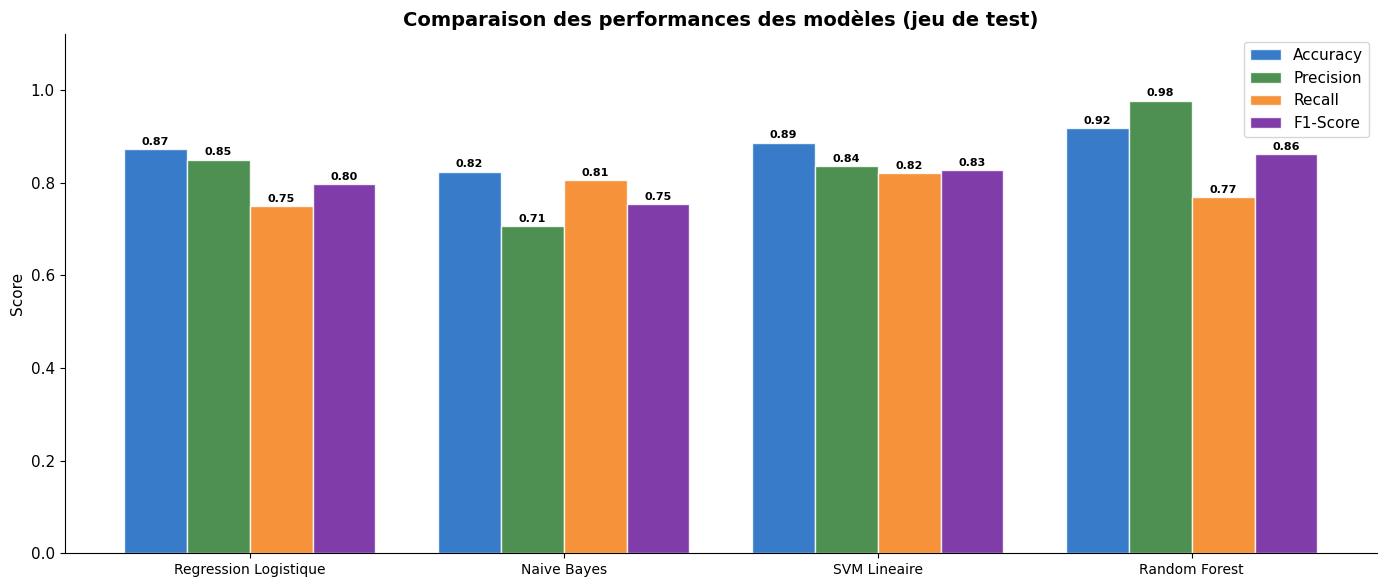

 Figure 4 sauvegardée


In [ ]:
# Figure 4 : Comparaison des métriques
fig, ax = plt.subplots(figsize=(14, 6))

metrics_list = ['accuracy', 'precision', 'recall', 'f1']
labels_list  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names  = list(results.keys())
x      = np.arange(len(model_names))
width  = 0.2
palette = ['#1565C0', '#2E7D32', '#F57F17', '#6A1B9A']

for i, (metric, label) in enumerate(zip(metrics_list, labels_list)):
    vals = [results[n][metric] for n in model_names]
    bars = ax.bar(x + i*width, vals, width,
                  label=label, color=palette[i], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Score')
ax.set_title('Comparaison des performances des modèles (jeu de test)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig4_comparaison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 4 sauvegardée')

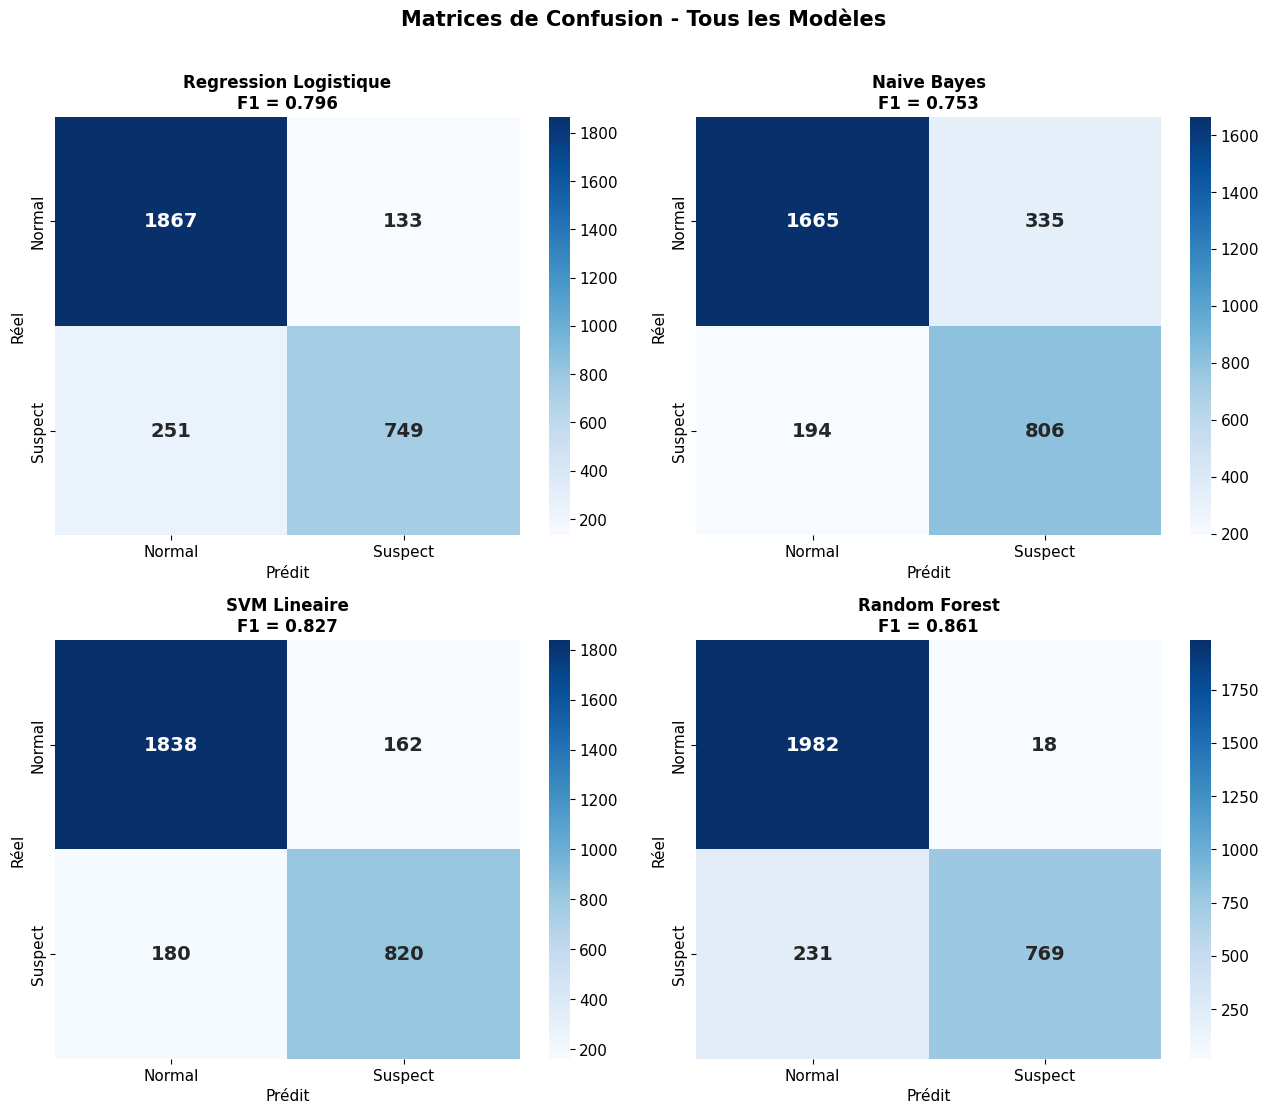

 Figure 5 sauvegardée


In [ ]:
# Figure 5 : Matrices de confusion
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.ravel()

for idx, (nom, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues',
                annot_kws={'size': 14, 'fontweight': 'bold'},
                xticklabels=['Normal', 'Suspect'],
                yticklabels=['Normal', 'Suspect'])
    axes[idx].set_title(f'{nom}\nF1 = {res["f1"]:.3f}',
                         fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Réel')
    axes[idx].set_xlabel('Prédit')

plt.suptitle('Matrices de Confusion - Tous les Modèles',
              fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig5_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 5 sauvegardée')

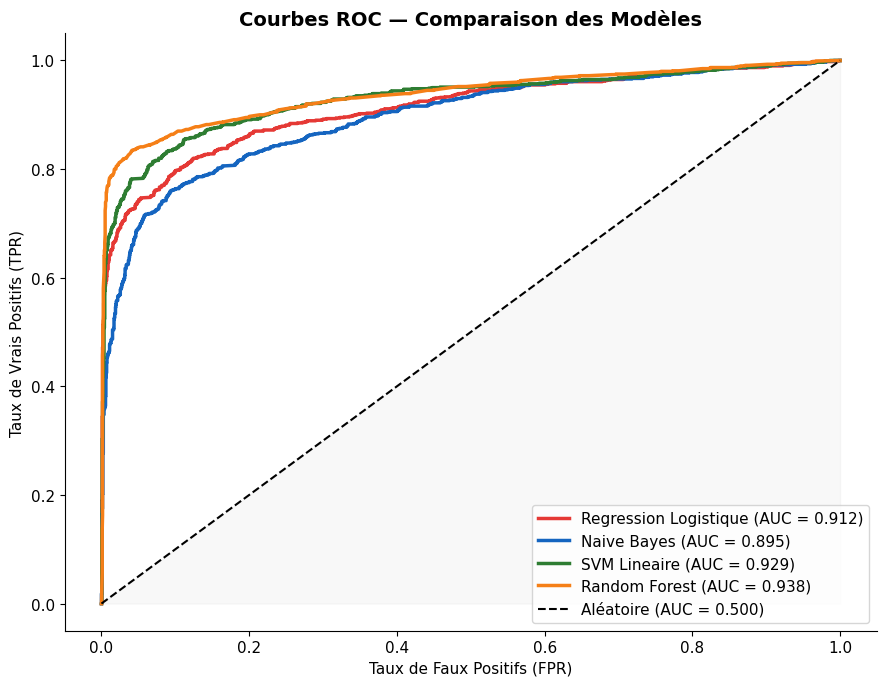

 Figure 6 sauvegardée


In [ ]:
# Figure 6 : Courbes ROC
fig, ax = plt.subplots(figsize=(9, 7))
roc_colors = ['#E53935', '#1565C0', '#2E7D32', '#F57F17']

for (nom, res), color in zip(results.items(), roc_colors):
    modele = res['modele']
    if hasattr(modele, 'predict_proba'):
        y_score = modele.predict_proba(X_test_tfidf)[:, 1]
    elif hasattr(modele, 'decision_function'):
        y_score = modele.decision_function(X_test_tfidf)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{nom} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aléatoire (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR)')
ax.set_title('Courbes ROC — Comparaison des Modèles', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig6_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 6 sauvegardée')

In [ ]:
# Rapport de classification détaillé du meilleur modèle
print(f'\n=== Rapport détaillé - {best_nom} ===')
print(classification_report(
    y_test,
    results[best_nom]['y_pred'],
    target_names=['Normal (0)', 'Suspect (1)']
))


=== Rapport détaillé - Random Forest ===
              precision    recall  f1-score   support

  Normal (0)       0.90      0.99      0.94      2000
 Suspect (1)       0.98      0.77      0.86      1000

    accuracy                           0.92      3000
   macro avg       0.94      0.88      0.90      3000
weighted avg       0.92      0.92      0.91      3000



---
##  PARTIE 6 - Sauvegarde du modèle

In [ ]:
# Sauvegarde du meilleur modèle et du vectoriseur TF-IDF
with open('best_model.pkl', 'wb') as f:
    pickle.dump(results[best_nom]['modele'], f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Sauvegarde des résultats en JSON
results_clean = {
    nom: {
        k: float(v) if isinstance(v, (float, np.floating)) else v
        for k, v in r.items()
        if k not in ['modele', 'y_pred']
    }
    for nom, r in results.items()
}
results_clean['_best'] = best_nom

with open('results.json', 'w') as f:
    json.dump(results_clean, f, indent=2)

print(f' Modèle sauvegardé  : best_model.pkl ({best_nom})')
print(f' Vectoriseur sauvé  : tfidf_vectorizer.pkl')
print(f' Résultats sauvés   : results.json')
print(f' Figures sauvées    : fig1 à fig6.png')

 Modèle sauvegardé  : best_model.pkl (Random Forest)
 Vectoriseur sauvé  : tfidf_vectorizer.pkl
 Résultats sauvés   : results.json
 Figures sauvées    : fig1 à fig6.png


---
##  PARTIE 7 - Téléchargement des fichiers depuis Colab

In [ ]:
# Téléchargeons tous les fichiers produits directement depuis Colab
from google.colab import files

fichiers = [
    'fig1_distribution.png',
    'fig2_longueur.png',
    'fig3_top_mots.png',
    'fig4_comparaison.png',
    'fig5_confusion.png',
    'fig6_roc.png',
    'best_model.pkl',
    'tfidf_vectorizer.pkl',
    'results.json',
]

for f in fichiers:
    try:
        files.download(f)
        print(f'  {f}')
    except Exception as e:
        print(f' {f} — {e}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  fig1_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  tfidf_vectorizer.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  results.json


---
##  PARTIE 8 - Test manuel du modèle

In [ ]:
# Teste le modèle sur des exemples de ton choix
def predire(tweet):
    """Prédit si un tweet est suspect ou normal."""
    clean = nettoyer_tweet(tweet)
    X = tfidf.transform([clean])
    modele = results[best_nom]['modele']
    pred = modele.predict(X)[0]

    if hasattr(modele, 'predict_proba'):
        proba = modele.predict_proba(X)[0]
        score = proba[1]
    elif hasattr(modele, 'decision_function'):
        d = modele.decision_function(X)[0]
        score = min(max((d + 2) / 4, 0), 1)
    else:
        score = float(pred)

    label = ' SUSPECT' if pred == 1 else ' NORMAL'
    print(f'Tweet    : {tweet}')
    print(f'Nettoyé  : {clean}')
    print(f'Résultat : {label}  (score suspect : {score:.1%})')
    print('-' * 60)

# Exemples de test
tweets_test = [
    "Having a wonderful day with my family, so grateful!",
    "I hate everything, I want to disappear nobody cares",
    "Just finished a great workout, feeling amazing today",
    "feeling so depressed and alone, nothing is going right",
    "Beautiful sunset tonight, life is good!",
]

print(f'=== Test du modèle : {best_nom} ===\n')
for tweet in tweets_test:
    predire(tweet)

=== Test du modèle : Random Forest ===

Tweet    : Having a wonderful day with my family, so grateful!
Nettoyé  : having wonderful day family grateful
Résultat :  NORMAL  (score suspect : 3.0%)
------------------------------------------------------------
Tweet    : I hate everything, I want to disappear nobody cares
Nettoyé  : hate everything want disappear nobody cares
Résultat :  SUSPECT  (score suspect : 84.0%)
------------------------------------------------------------
Tweet    : Just finished a great workout, feeling amazing today
Nettoyé  : finished great workout feeling amazing today
Résultat :  NORMAL  (score suspect : 5.0%)
------------------------------------------------------------
Tweet    : feeling so depressed and alone, nothing is going right
Nettoyé  : feeling depressed alone nothing going right
Résultat :  NORMAL  (score suspect : 19.0%)
------------------------------------------------------------
Tweet    : Beautiful sunset tonight, life is good!
Nettoyé  : beautiful